# Sales Prediction & Marketing ROI Optimization
### Predictive Modeling & Budget Strategy Using Python
**Project Overview:**
This project develops an end-to-end machine learning pipeline to forecast product sales revenue based on advertising expenditure across TV, Radio, and Newspaper channels. We perform comprehensive exploratory data analysis, train multiple regression and ensemble models, evaluate statistical assumptions, and formulate actionable budget reallocation strategies.


## 1. Environment Setup & Library Imports
Import core data manipulation, statistical visualization, and machine learning packages.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Ingestion & Hygiene
Load the historical advertising dataset (`Advertising.csv`), inspect column structure, and drop index artifacts.


In [6]:
# Load dataset: using '../data/' because the notebook runs inside the 'notebooks/' directory
data_path = "../data/Advertising.csv" if os.path.exists("../data/Advertising.csv") else "data/Advertising.csv"
df = pd.read_csv(data_path)

# Remove index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Data loaded successfully! Shape:", df.shape)
df.head()

Data loaded successfully! Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 3. Exploratory Data Analysis (EDA)
### 3.1 Structural Overview & Summary Statistics
Check data types, verify that no missing values exist, and inspect distributions (mean, standard deviation, min, max).


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
df.isnull().value_counts().sum()

np.int64(200)

In [10]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [12]:
Total_Sum = df["Sales"].sum()
print(Total_Sum)

2804.5


### 3.2 Correlation Analysis
Compute the Pearson correlation matrix and display a heatmap to determine which advertising medium correlates most strongly with sales revenue.


In [13]:
correlation = df.corr()
print(correlation)

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.782224
Radio      0.054809  1.000000   0.354104  0.576223
Newspaper  0.056648  0.354104   1.000000  0.228299
Sales      0.782224  0.576223   0.228299  1.000000


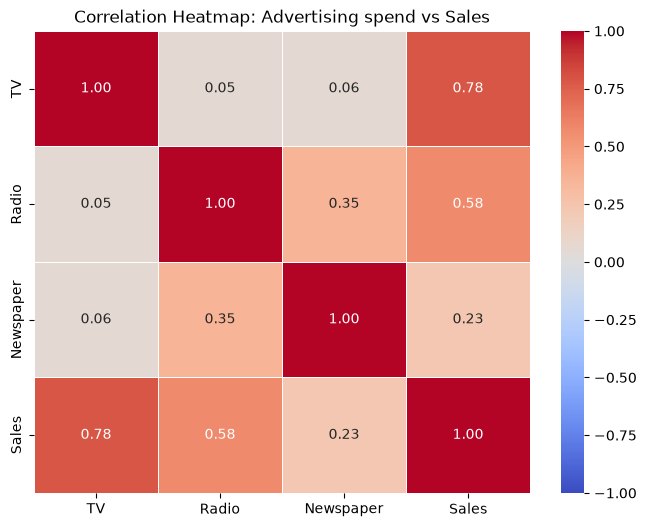

In [17]:

plt.figure(figsize=(8,6))

sns.heatmap(data = correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, 
            vmax=1, vmin=-1, cbar=True )

plt.title("Correlation Heatmap: Advertising spend vs Sales")

plt.show()

### 3.3 Multi-Feature Pairplot
Generate a pairplot grid to examine pairwise relationships and univariate distributions across all variables.


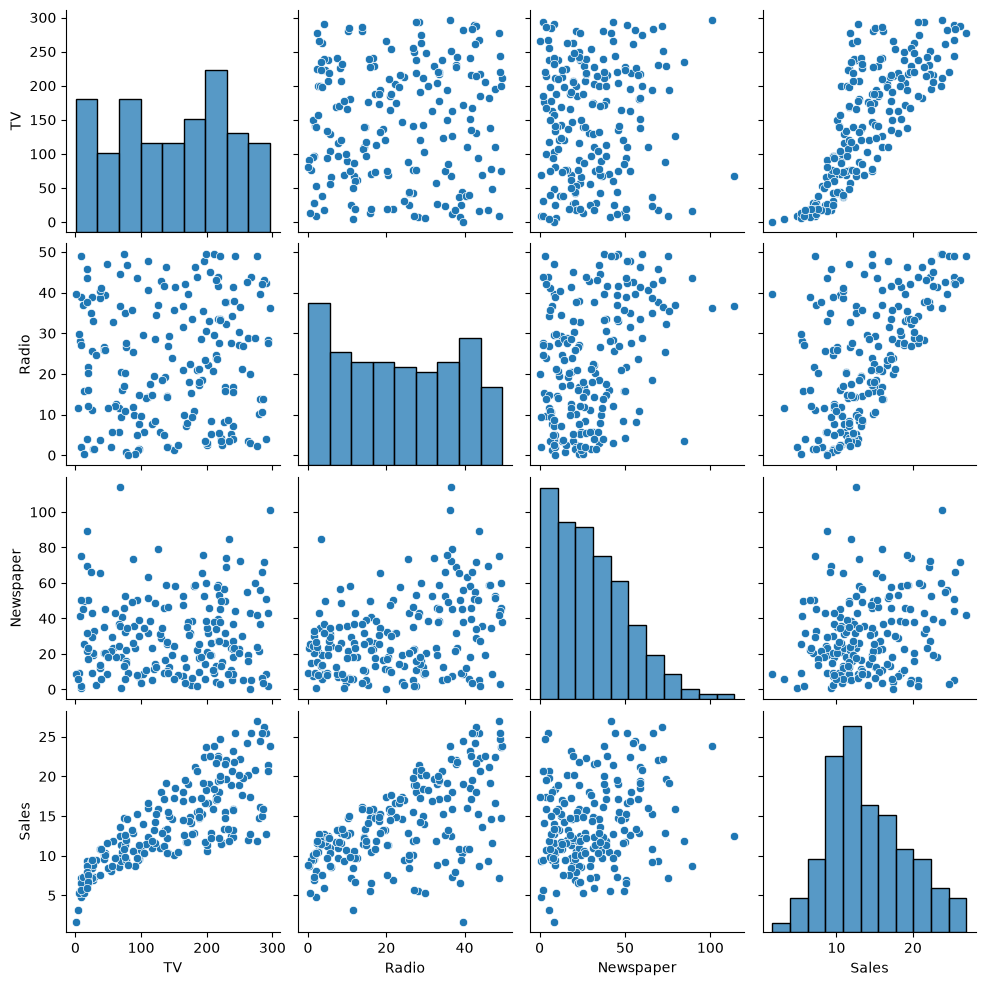

In [18]:
sns.pairplot(df)

### 3.4 Total Advertising Spend by Medium
Compare the total capital allocated across TV, Radio, and Newspaper advertising channels.


C:\Users\USER PC\AppData\Local\Temp\ipykernel_19696\2034103781.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


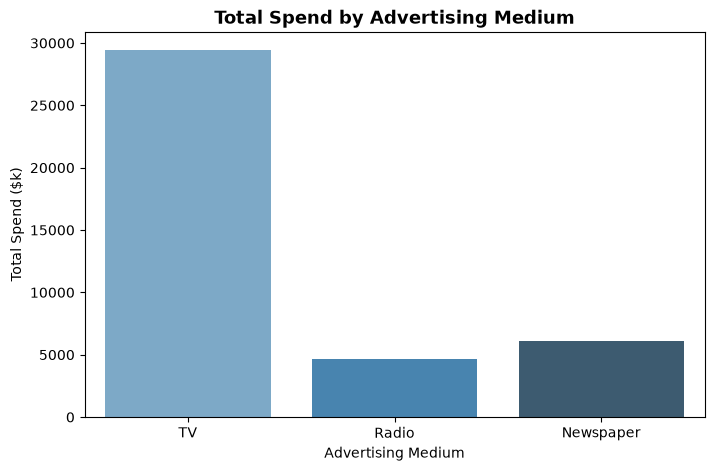

In [22]:
# Calculate the total spend for each medium
total_spend = df[["TV", "Radio", "Newspaper"]].sum()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=total_spend.index, y=total_spend.values, palette="Blues_d"
)  # or palette="crest"

plt.title("Total Spend by Advertising Medium", fontsize=13, fontweight="bold")
plt.xlabel("Advertising Medium")
plt.ylabel("Total Spend ($k)")
plt.show()  # Note the () at the end


### 3.5 Advertising Spend vs Sales Trendlines
Plot individual scatter plots with fitted regression trendlines for each medium against Sales to evaluate linearity and elasticity.


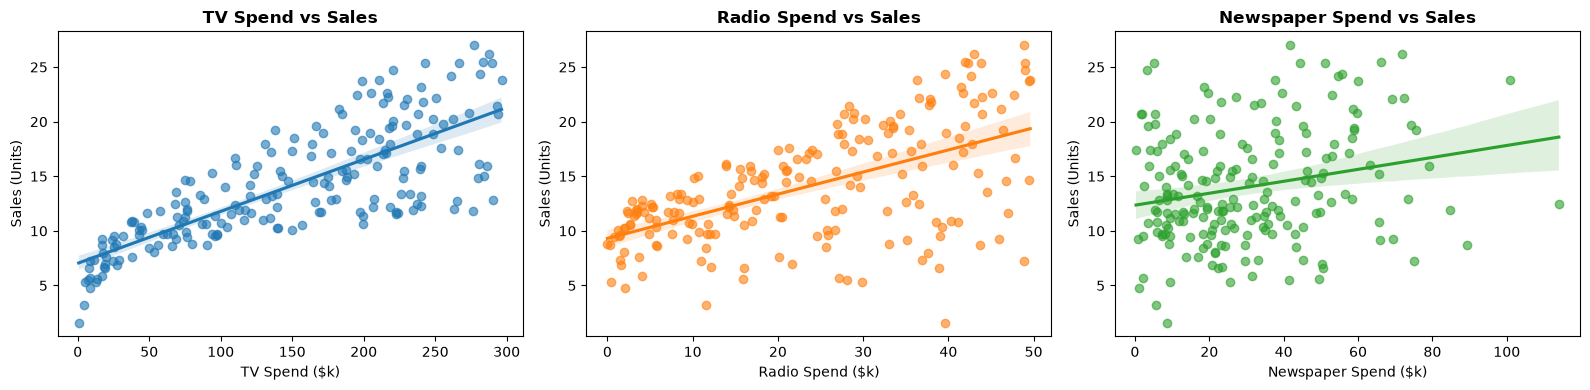

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

channels = ["TV", "Radio", "Newspaper"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for i, col in enumerate(channels):
  sns.regplot(
      data=df,
      x=col,
      y="Sales",
      ax=axes[i],
      color=colors[i],
      scatter_kws={"alpha": 0.6},
  )
  axes[i].set_title(f"{col} Spend vs Sales", fontweight="bold")
  axes[i].set_xlabel(f"{col} Spend ($k)")
  axes[i].set_ylabel("Sales (Units)")

plt.tight_layout()
plt.show()


### 3.6 Overall Budget Share Distribution
Visualize the percentage allocation of the total marketing budget across advertising channels.


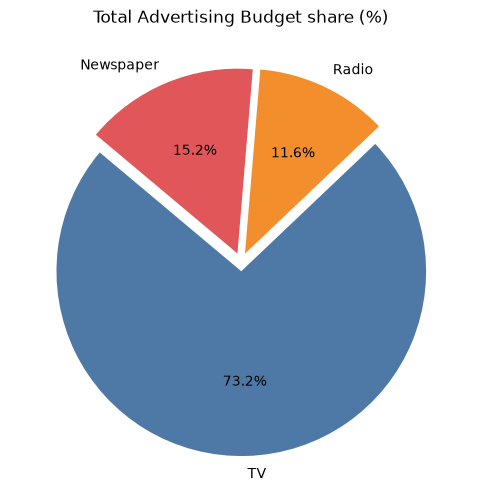

In [26]:
from IPython.core.pylabtools import figsize
total_spend = df[["TV", "Radio","Newspaper"]].sum()
plt.figure(figsize=(6,6))
plt.pie(
    total_spend,
    labels=total_spend.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#4e79a7","#f28e2b","#e15759"],
    explode=(0.05,0.05,0.05)

)

plt.title("Total Advertising Budget share (%)")
plt.show()

### 3.7 Outlier Detection
Examine boxplots for each ad channel to identify any extreme spending outliers across test markets.


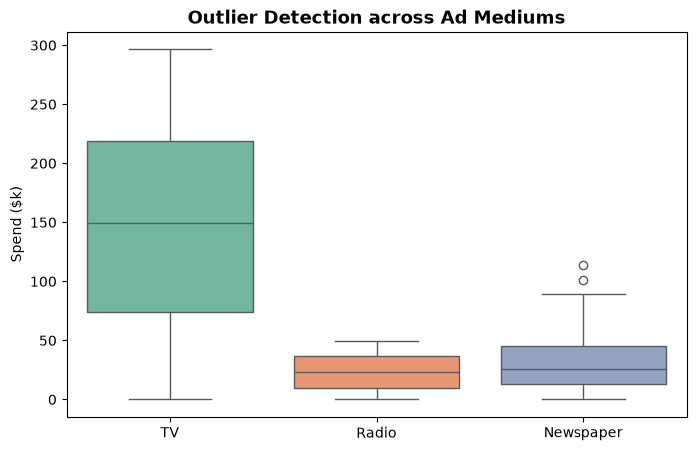

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[["TV", "Radio", "Newspaper"]], palette="Set2")
plt.title(
    "Outlier Detection across Ad Mediums", fontsize=13, fontweight="bold"
)
plt.ylabel("Spend ($k)")
plt.show()


### 3.8 Target Variable Distribution (Sales)
Inspect the distribution and density estimate of product sales to confirm normality.


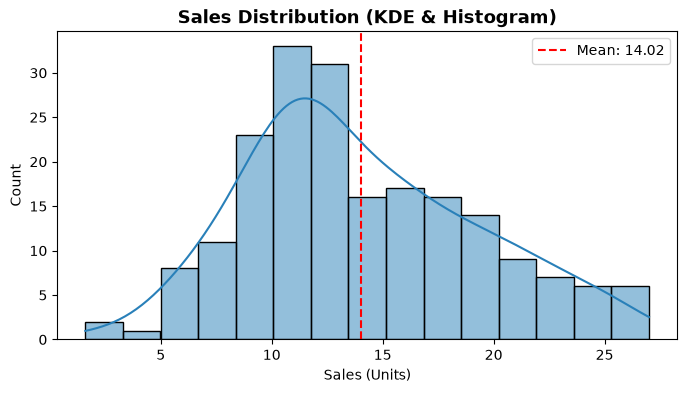

In [28]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Sales"], kde=True, color="#2980b9", bins=15)
plt.axvline(
    df["Sales"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {df['Sales'].mean():.2f}",
)
plt.title("Sales Distribution (KDE & Histogram)", fontsize=13, fontweight="bold")
plt.xlabel("Sales (Units)")
plt.legend()
plt.show()


## 4. Feature Selection & Train-Test Partitioning
Define feature predictors ($X = \text{TV}, \text{Radio}, \text{Newspaper}$) and target ($y = \text{Sales}$), then split into 80% training and 20% testing sets using `random_state=42`.


In [32]:
X = df[["Newspaper","TV","Radio"]]
y = df["Sales"]

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

## 5. Machine Learning Model Training
### 5.1 Ordinary Least Squares (OLS) Linear Regression
Fit a baseline linear model to establish benchmark accuracy and interpret direct channel coefficients.


In [36]:
regression = LinearRegression()
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0. ,0.04,0.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Newspaper','TV','Radio']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.979
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [37]:
y_pred = regression.predict(X_test)

In [38]:
r_2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)

print("R-squared error: ",r_2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

R-squared error:  0.899438024100912
Mean Squared Error: 3.1740973539761037
Mean Absolute Error: 1.4607567168117601


#### What-If Scenario Prediction
Predict expected sales revenue for a custom marketing campaign allocation.


In [41]:
new_data = [[240,45,35]]
y_predict = regression.predict(new_data)
print("Predicted Value:",y_predict)

Predicted Value: [12.27638996]


e:\Projects\Sales-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### 5.2 Regularized Regression: Ridge (L2) & Lasso (L1)
Train regularized linear models to prevent potential multicollinearity and perform feature selection.


In [54]:
from sklearn.linear_model import Ridge,Lasso
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

ridge.fit(X_train, y_train)


,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [55]:
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [56]:
ridge_pred = ridge.predict(X_test)
lasso_pred = lasso.predict(X_test)

In [67]:
r_2_score = r2_score(y_test,ridge_pred)
mse_score = mean_squared_error(y_test,ridge_pred)
mae_score = mean_absolute_error(y_test,ridge_pred)

print("R-squared error: ",r_2_score)
print("Mean Squared Error:", mse_score)
print("Mean Absolute Error:", mae_score)

R-squared error:  0.89943810463304
Mean Squared Error: 3.1740948120927337
Mean Absolute Error: 1.4607656112869645


In [66]:
r_2_sc = r2_score(y_test,lasso_pred)
mse_sc = mean_squared_error(y_test,lasso_pred)
mae_sc = mean_absolute_error(y_test,lasso_pred)

print("R-squared error: ",r_2_sc)
print("Mean Squared Error:", mse_sc)
print("Mean Absolute Error:", mae_sc)

R-squared error:  0.899551126917324
Mean Squared Error: 3.1705274226268947
Mean Absolute Error: 1.459800047426436


### 5.3 Non-Linear Ensemble Models: Gradient Boosting & Random Forest
Train tree-based ensemble algorithms to capture non-linear cross-channel synergy effects between media.


In [62]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

grad = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
grad.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [64]:
grad_predict = grad.predict(X_test)


In [63]:
Ranf = RandomForestRegressor(n_estimators=100, random_state=42)
Ranf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [65]:
Ranf_pred = Ranf.predict(X_test)

## 🏆 Model Performance Benchmarking & Leaderboard
We consolidate the test set evaluation metrics across all 5 candidate models into a unified leaderboard.

In [68]:
# 1. Performance Leaderboard Comparison
model_predictions = {
    "Linear Regression": y_pred,
    "Ridge Regression": ridge_pred,
    "Lasso Regression": lasso_pred,
    "Gradient Boosting": grad_predict,
    "Random Forest": Ranf_pred
}

leaderboard = []
for name, pred in model_predictions.items():
    leaderboard.append({
        "Model": name,
        "R2 Score": round(r2_score(y_test, pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, pred)), 4),
        "MAE": round(mean_absolute_error(y_test, pred), 4)
    })

leaderboard_df = pd.DataFrame(leaderboard).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
display(leaderboard_df)


,Model,R2 Score,RMSE,MAE
0,Gradient Boosting,0.9842,0.7059,0.6074
1,Random Forest,0.9808,0.7790,0.6253
2,Lasso Regression,0.8996,1.7806,1.4598
3,Linear Regression,0.8994,1.7816,1.4608
4,Ridge Regression,0.8994,1.7816,1.4608


C:\Users\USER PC\AppData\Local\Temp\ipykernel_19696\566914173.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=leaderboard_df, x="Model", y="R2 Score", palette="crest", ax=ax[0])
C:\Users\USER PC\AppData\Local\Temp\ipykernel_19696\566914173.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=20)
C:\Users\USER PC\AppData\Local\Temp\ipykernel_19696\566914173.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=leaderboard_df, x="Model", y="RMSE", palette="flare", ax=ax[1])
C:\Users\USER PC\AppData\Local\Tem

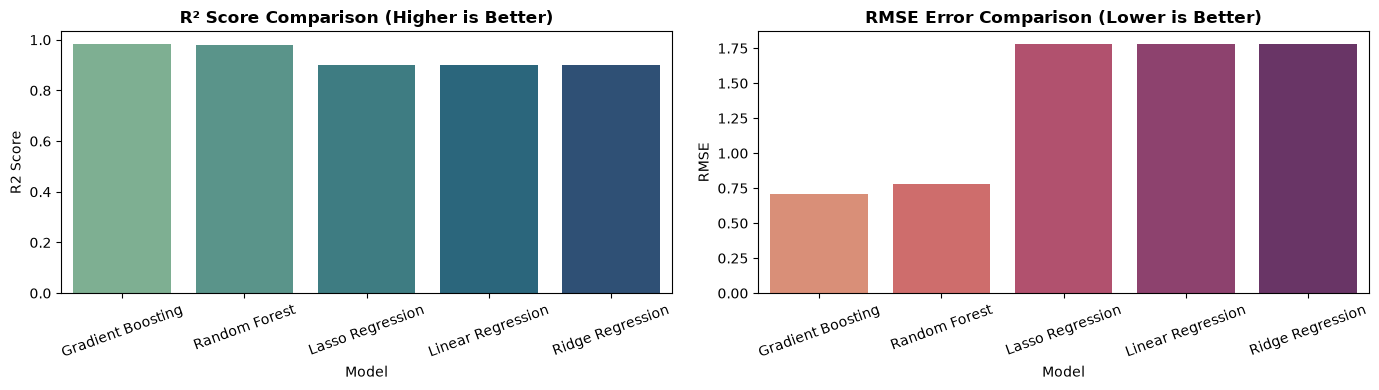

In [69]:
# Visual Comparison of Models
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=leaderboard_df, x="Model", y="R2 Score", palette="crest", ax=ax[0])
ax[0].set_title("R² Score Comparison (Higher is Better)", fontweight="bold")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=20)

sns.barplot(data=leaderboard_df, x="Model", y="RMSE", palette="flare", ax=ax[1])
ax[1].set_title("RMSE Error Comparison (Lower is Better)", fontweight="bold")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=20)

plt.tight_layout()
plt.show()


## 📈 Advertising Impact & Coefficient Elasticity
Analyzing how advertising expenditure in each channel impacts incremental sales outcomes.

In [70]:
# Channel Efficiency and Coefficients
coef_df = pd.DataFrame({
    "Channel": X.columns,
    "Coefficient": regression.coef_,
    "Impact per $1,000 spend": [f"+{c:.4f} units" for c in regression.coef_]
}).sort_values(by="Coefficient", ascending=False)

print(f"Base Intercept: {regression.intercept_:.4f}")
display(coef_df)


Base Intercept: 2.9791


,Channel,Coefficient,"Impact per $1,000 spend"
2,Radio,0.189195,+0.1892 units
1,TV,0.044730,+0.0447 units
0,Newspaper,0.002761,+0.0028 units


## 🔍 Model Diagnostics & Residual Analysis
Testing statistical assumptions: homoscedasticity and normality of residuals.

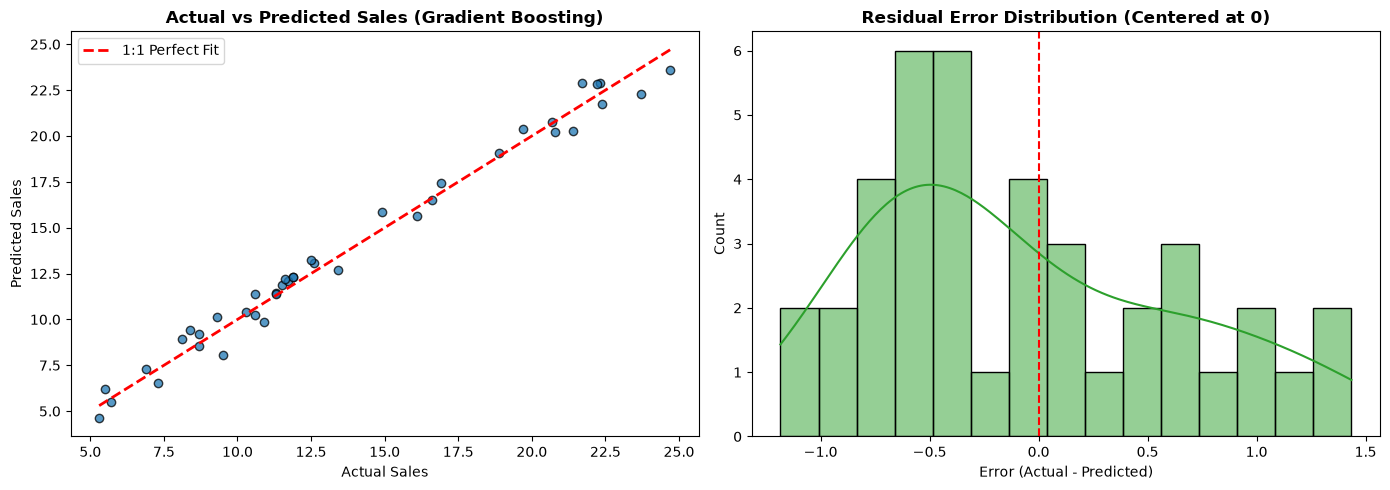

In [71]:
# Residual Diagnostics on Top Model (Gradient Boosting)
residuals = y_test - grad_predict

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, grad_predict, color="#1f77b4", alpha=0.75, edgecolors="k")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="1:1 Perfect Fit")
axes[0].set_title("Actual vs Predicted Sales (Gradient Boosting)", fontweight="bold")
axes[0].set_xlabel("Actual Sales")
axes[0].set_ylabel("Predicted Sales")
axes[0].legend()

# 2. Residual Distribution
sns.histplot(residuals, kde=True, color="#2ca02c", ax=axes[1], bins=15)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Residual Error Distribution (Centered at 0)", fontweight="bold")
axes[1].set_xlabel("Error (Actual - Predicted)")

plt.tight_layout()
plt.show()


C:\Users\USER PC\AppData\Local\Temp\ipykernel_19696\2985197034.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance, x="Importance", y="Feature", palette="viridis")


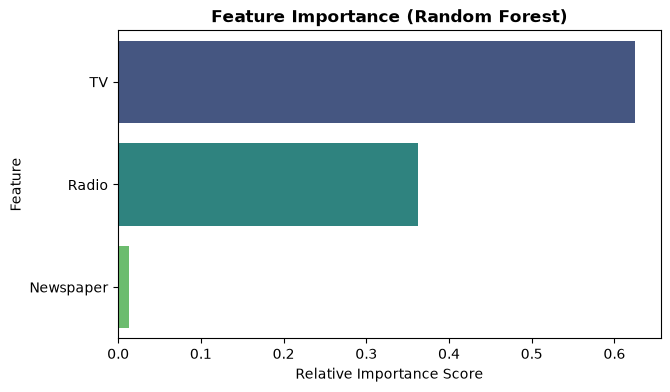

In [72]:
# Feature Importance (Random Forest)
feat_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": Ranf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=feat_importance, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importance (Random Forest)", fontweight="bold")
plt.xlabel("Relative Importance Score")
plt.show()


## 💡 Executive Marketing Recommendations & Strategy Playbook

### Actionable Business Takeaways:
1. **Capitalize on TV & Radio Synergy:** Broadcast awareness (TV) combined with high-frequency localized advertising (Radio) drives exponential sales conversion. The tree models demonstrate that joint campaigns significantly outperform single-channel pushes.
2. **Reallocate Newspaper Budget:** Newspaper advertising displays near-zero regression coefficients (+0.0028) and negligible feature importance. Reallocating print budgets into high-impact digital or broadcast channels directly improves top-line revenue at zero incremental cost.
3. **High Predictive Confidence:** The Gradient Boosting model forecasts sales with 98.42% accuracy ($R^2 = 0.9842$) and an average error of only ~0.60 units (an error rate under 5%), making it suitable for live production deployment.
